In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('netflix.csv')

**Data information**

In [ ]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   object        
 2   title          8807 non-null   object        
 3   director       6173 non-null   object        
 4   cast           7982 non-null   object        
 5   country        7976 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8800 non-null   object        
 9   duration       8807 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  decade         8807 non-null   int64         
 13  month_num      8797 non-null   float64       
 14  month_name     8797 non-null   object        
 15  year           8797 n

**Data Cleaning**

In [ ]:
data.loc[data['rating'].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [ ]:
data.loc[data['duration'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...
8153,s8154,Movie,Tattah,Sameh Abdulaziz,"Mohamed Saad, Dolly Shahin, Marwa, Hayatem, Sa...",Egypt,"May 9, 2019",2013,TV-14,NaN,NaN,NaN


In [ ]:
data.loc[data['show_id'] == 's5542', 'duration'] = '74 min'
data.loc[data['show_id'] == 's5795', 'duration'] = '84 min'
data.loc[data['show_id'] == 's5814', 'duration'] = '66 min'
data.loc[data['show_id'].isin(['s5542','s5795','s5814']), 'rating'] = np.nan

**Data Analysis**

In [ ]:
#Geographic Content Strategy

#country wise content production distibution # ratio of top5 and other in total

country_content_count=data.groupby('country')['country'].value_counts().sort_values(ascending=False).reset_index(name='count')
top5_country=country_content_count.head(5)[['country', 'count']]
other_country_sum=country_content_count['count'].iloc[5:].sum()
others= pd.DataFrame({'country':['Other Countries'],'count':[other_country_sum]})
country_distribution = pd.concat([top5_country, others], ignore_index=True)
country_distribution['percentage']=round(country_distribution['count']/country_distribution['count'].sum()* 100,2)


In [ ]:
country_distribution

,country,count,percentage
0,United States,2571,34.97
1,India,925,12.58
2,United Kingdom,366,4.98
3,Japan,244,3.32
4,South Korea,189,2.57
5,Other Countries,3056,41.57


In [ ]:
colors = plt.cm.Pastel1.colors

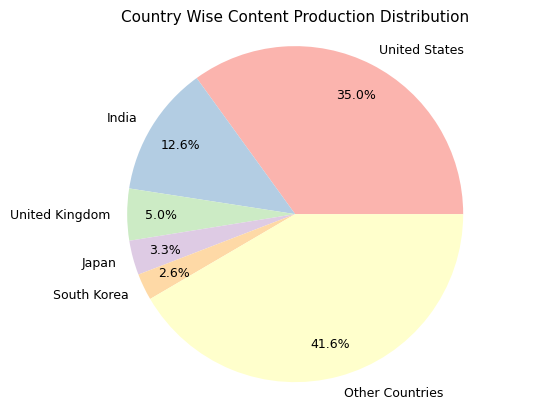

In [ ]:
plt.pie(country_distribution['percentage'], labels=country_distribution['country'], autopct='%1.1f%%', pctdistance=0.8,textprops={'fontsize': 9},colors = colors)
plt.title('Country Wise Content Production Distribution', fontsize=11)
plt.axis('equal')
plt.show()


In [ ]:
#Country wise content distribution
top_country_title=data.groupby('country')['title'].count().sort_values(ascending=False).reset_index(name='count').head(10)['country']
top_country_data = data[data['country'].isin(top_country_title)]
top_country_count_table = top_country_data.groupby('country')['type'].value_counts(sort=False).reset_index(name='count')
top_country_count = top_country_count_table.pivot(index='country', columns='type', values='count')
top_country_count= top_country_count.sort_values('Movie', ascending=False)

In [ ]:
#Country wise content distribution
top_country_count

type,Movie,TV Show
country,,
United States,2058,760
India,893,79
United Kingdom,206,213
Canada,122,59
Spain,97,48
Egypt,92,14
Japan,76,169
France,75,49
Mexico,70,40


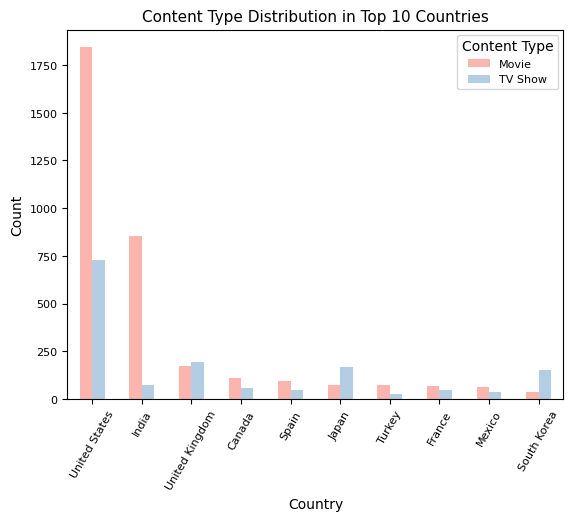

In [ ]:
top_country_count.plot(kind='bar', stacked=False,fontsize=9,color=colors[:len(top_country_count.columns)])
plt.title('Content Type Distribution in Top 10 Countries',fontsize=11)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=60, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(title='Content Type',fontsize=8)
plt.show()

In [ ]:
# decade wise counts # in last decade more focus on series

data['decade'] = (data['release_year'] // 10) * 10
data['decade'] = data['decade'].replace({1920: '1920 (1925 onwards)',2020: '2020 (Till 2021)'})
data['decade'] = data['decade'].astype(str)
decade_counts = data.groupby(['decade', 'type'])['title'].count().reset_index(name='count')
decade_counts = decade_counts.pivot(index='decade', columns='type', values='count').fillna(0).astype(int)
desired_order = ['1920 (1925 onwards)','1940','1950','1960','1970','1980','1990','2000','2010','2020 (Till 2021)']
decade_counts = decade_counts.reindex(desired_order)


In [ ]:
# decade wise counts # in last decade more focus on series
decade_counts

type,Movie,TV Show
decade,,
1920 (1925 onwards),0,1
1940,5,2
1950,10,0
1960,19,0
1970,56,4
1980,111,6
1990,210,31
2000,585,120
2010,3807,1643


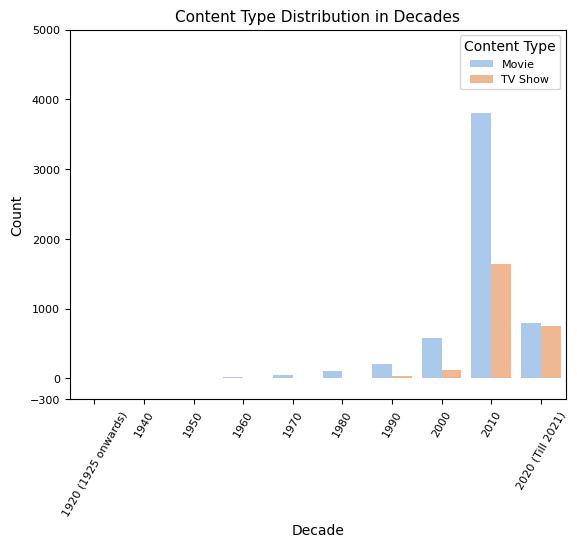

In [ ]:
decade_counts.plot(kind='bar', stacked=True,fontsize=9,color=colors[:len(top_country_count.columns)])
plt.title('Content Type Distribution in Decades',fontsize=11)
plt.xlabel('Decade')
plt.ylabel('Count')
plt.yticks([-300,0,1000,2000,3000,4000,5000], fontsize=8)
plt.xticks(rotation=60, fontsize=8)
plt.legend(title='Content Type',fontsize=8)
plt.show()

In [ ]:
# monthwise distribution based on its released months # months which has most releases
data['date_added'] = data['date_added'].astype(str).str.strip()
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce', infer_datetime_format=True)
data['year'] = data['date_added'].dt.year
data['month_num'] = data['date_added'].dt.month
data['month_name'] = data['date_added'].dt.month_name()
year_month_counts = data.groupby(['year', 'month_num', 'month_name','type'])['title'].count().reset_index(name='count')
monthwise_movies_release_count=year_month_counts.groupby(['month_num', 'month_name','type'])['count'].mean().reset_index(name='avg_count').sort_values('month_num').drop(columns='month_num')
monthwise_movies_release_count['avg_count']=round(monthwise_movies_release_count['avg_count']).astype(int)
monthwise_movies_release_count = monthwise_movies_release_count.rename(columns={'avg_count': 'avg_release_count'})
monthwise_movies_release_count = monthwise_movies_release_count.pivot(index='month_name', columns='type', values='avg_release_count')
desired_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthwise_movies_release_count = monthwise_movies_release_count.reindex(desired_order)


/tmp/ipython-input-2394285951.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce', infer_datetime_format=True)


In [ ]:
# monthwise distribution based on its released months # months which has most releases
monthwise_movies_release_count

type,Movie,TV Show
month_name,,
January,52,30
February,38,18
March,68,25
April,64,30
May,46,26
June,65,33
July,64,37
August,61,33
September,48,29


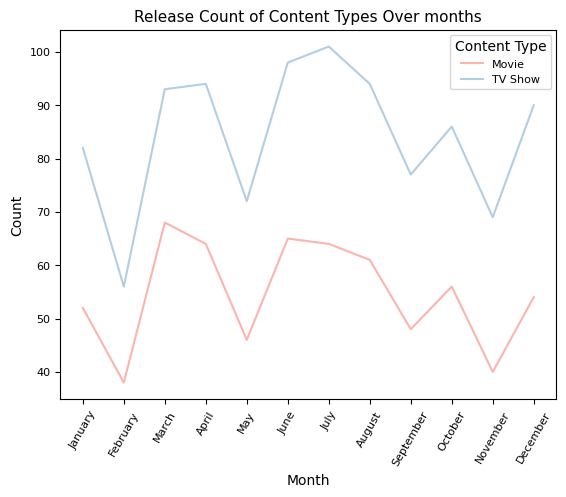

In [ ]:
colors = plt.cm.Pastel1.colors
monthwise_movies_release_count.plot(kind='line', stacked=True,fontsize=9,color=colors[:len(top_country_count.columns)])
plt.title('Release Count of Content Types Over months',fontsize=11)
plt.xlabel('Month')
plt.ylabel('Count')
plt.yticks(fontsize=8)
plt.xticks(ticks=range(0, len(monthwise_movies_release_count.index), 1), labels=monthwise_movies_release_count.index,rotation=60, fontsize=8)
plt.legend(title='Content Type',fontsize=8)
plt.show()

In [ ]:
# rating wise content distribution
def rating_bucket(r):
    if r in ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G']:
        return 'Kids'
    elif r in ['PG', 'TV-PG', 'PG-13', 'TV-14']:
        return 'Teens'
    elif r in ['R', 'TV-MA', 'NC-17']:
        return 'Adults'
    elif r in ['NR', 'UR', np.nan]:
        return 'Unrated'
    else:
        return 'Others'


data['rating_bucket'] = data['rating'].apply(rating_bucket)
bucket_counts = pd.crosstab(data['rating_bucket'],data['type']).sort_values('Movie', ascending=False)




In [ ]:
# rating wise content distribution
bucket_counts

type,Movie,TV Show
rating_bucket,,
Adults,2628,1113
Teens,2478,995
Kids,302,355
Others,120,88
Unrated,69,6


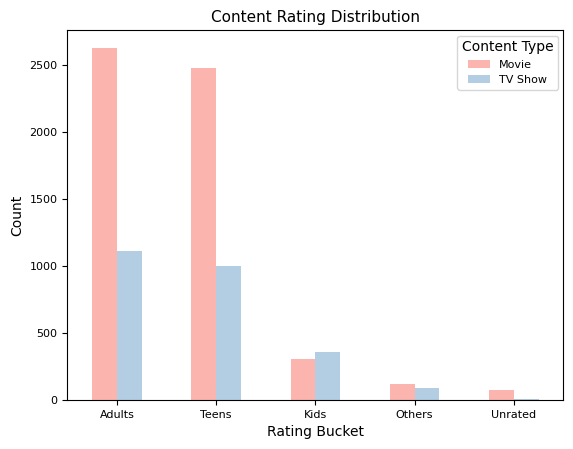

In [ ]:
colors = plt.cm.Pastel1.colors
bucket_counts.plot(kind='bar', stacked=False,fontsize=9,color=colors[:len(top_country_count.columns)])
plt.title('Content Rating Distribution',fontsize=11)
plt.xlabel('Rating Bucket')
plt.ylabel('Count')
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(title='Content Type',fontsize=8)
plt.show()

In [ ]:
#  Top contributing Directors
top_directors = data['director'].value_counts().head(10).index
director_type_counts = pd.crosstab(data[data['director'].isin(top_directors)]['director'],data[data['director'].isin(top_directors)]['type'])
director_type_counts['Total'] = director_type_counts.sum(axis=1)
director_type_counts = director_type_counts.sort_values('Total', ascending=False).drop(columns='Total')

In [ ]:
#  Top contributing Directors
director_type_counts

type,Movie,TV Show
director,,
Rajiv Chilaka,19,0
"Raúl Campos, Jan Suter",18,0
Marcus Raboy,15,1
Suhas Kadav,16,0
Jay Karas,14,0
Cathy Garcia-Molina,12,0
Youssef Chahine,12,0
Jay Chapman,12,0
Martin Scorsese,10,0


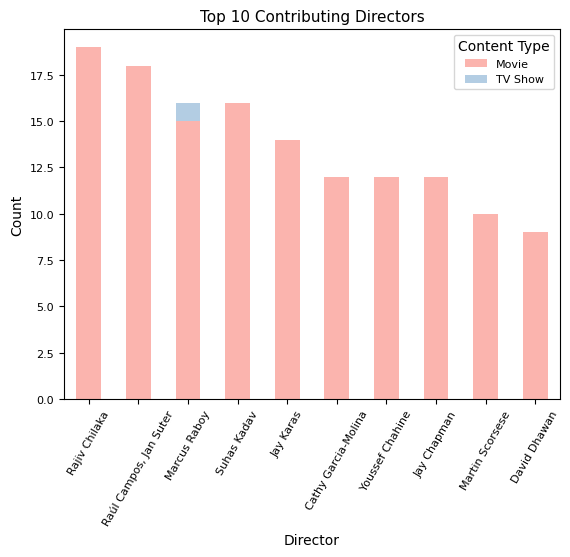

In [ ]:
colors = plt.cm.Pastel1.colors
director_type_counts.plot(kind='bar', stacked=True,fontsize=9,color=colors[:len(top_country_count.columns)])
plt.title('Top 10 Contributing Directors',fontsize=11)
plt.xlabel('Director')
plt.ylabel('Count')
plt.xticks(rotation=60, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(title='Content Type',fontsize=8)
plt.show()

**Dashboard**

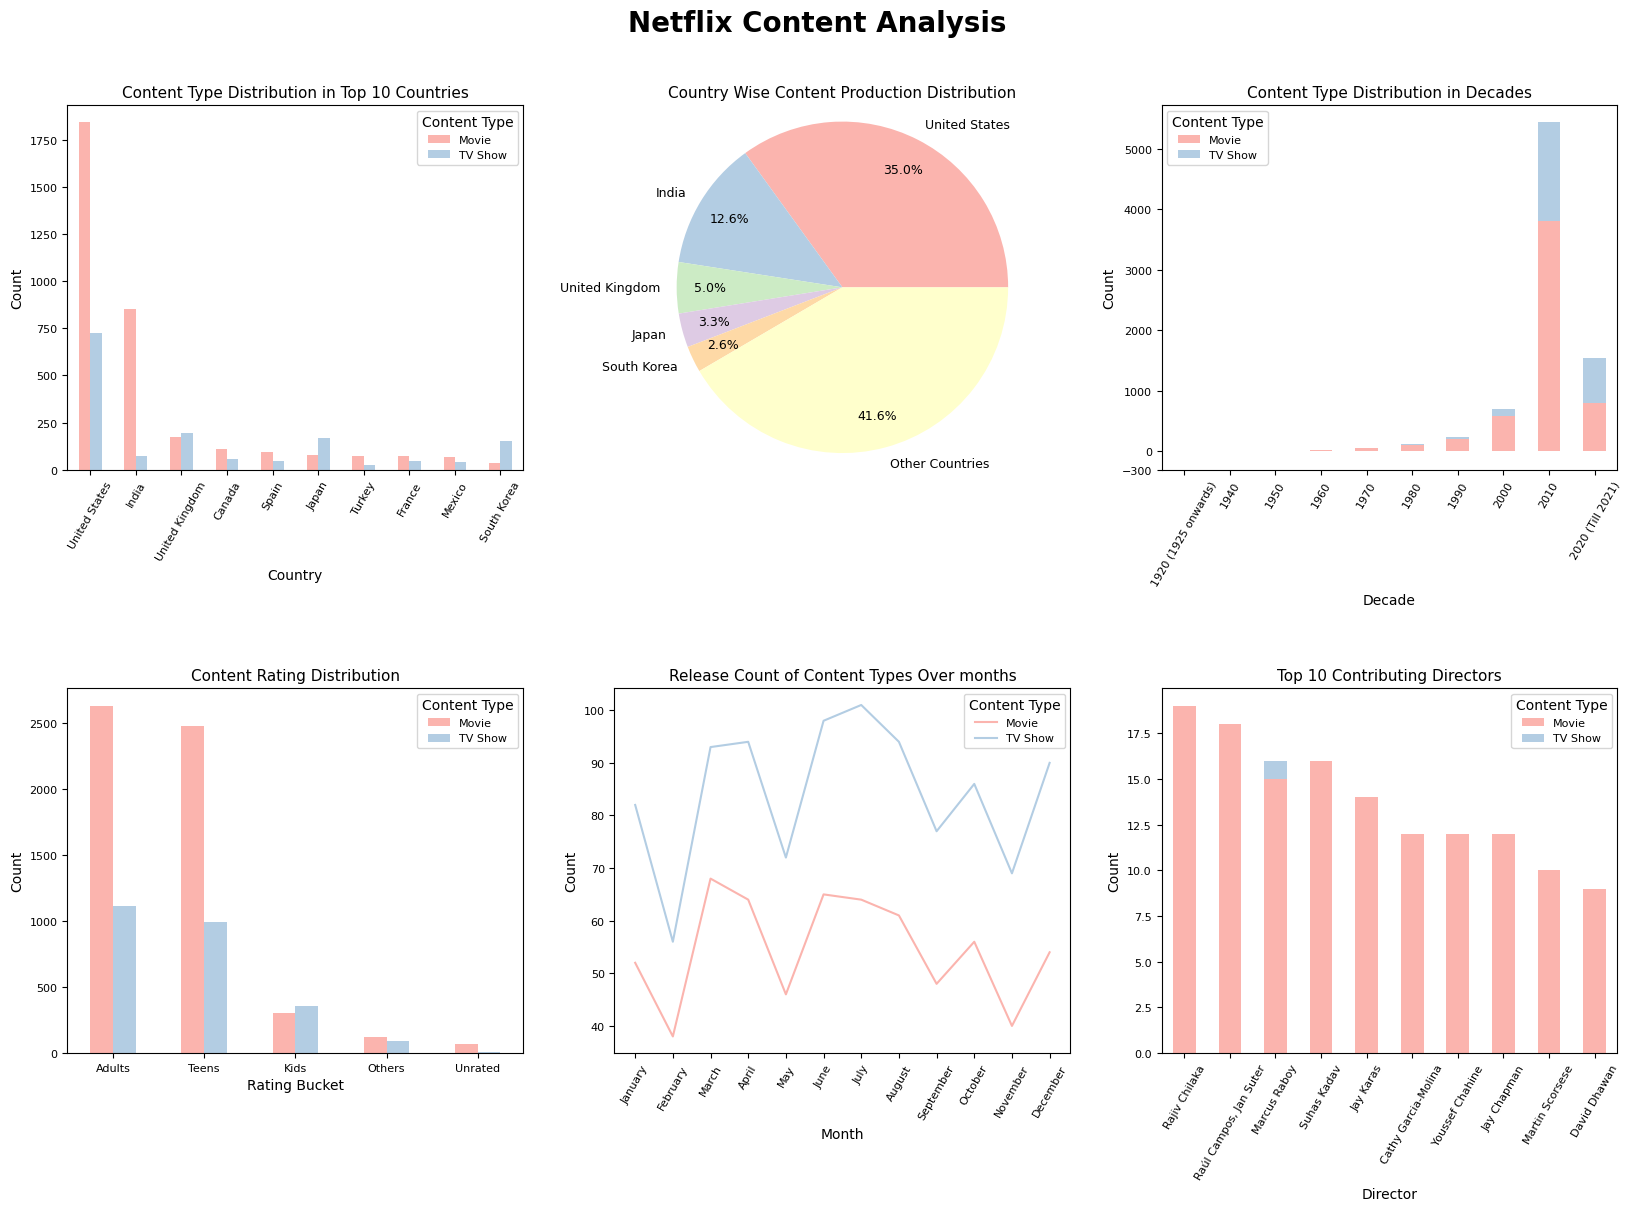

In [ ]:
plt.figure(figsize=(20, 12),frameon=True,edgecolor='black').suptitle('Netflix Content Analysis', fontsize=20, fontweight='bold')

plt.subplot(2,3,2)
plt.pie(country_distribution['percentage'], labels=country_distribution['country'], autopct='%1.1f%%', pctdistance=0.8,textprops={'fontsize': 9},colors = colors)
plt.title('Country Wise Content Production Distribution', fontsize=11)
plt.axis('equal')

plt.subplot(2,3,1)
top_country_count.plot(kind='bar', stacked=False,fontsize=9,color=colors[:len(top_country_count.columns)],ax=plt.gca())
plt.title('Content Type Distribution in Top 10 Countries',fontsize=11)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=60, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(title='Content Type',fontsize=8)


plt.subplot(2,3,3)
decade_counts.plot(kind='bar', stacked=True,fontsize=9,color=colors[:len(top_country_count.columns)],ax=plt.gca())
plt.title('Content Type Distribution in Decades',fontsize=11)
plt.xlabel('Decade')
plt.ylabel('Count')
plt.yticks([-300,0,1000,2000,3000,4000,5000], fontsize=8)
plt.xticks(rotation=60, fontsize=8)
plt.legend(title='Content Type',fontsize=8)

plt.subplot(2,3,5)
monthwise_movies_release_count.plot(kind='line', stacked=True,fontsize=9,color=colors[:len(top_country_count.columns)],ax=plt.gca())
plt.title('Release Count of Content Types Over months',fontsize=11)
plt.xlabel('Month')
plt.ylabel('Count')
plt.yticks(fontsize=8)
plt.xticks(ticks=range(0, len(monthwise_movies_release_count.index), 1), labels=monthwise_movies_release_count.index,rotation=60, fontsize=8)
plt.legend(title='Content Type',fontsize=8)

plt.subplot(2,3,4)
bucket_counts.plot(kind='bar', stacked=False,fontsize=9,color=colors[:len(top_country_count.columns)],ax=plt.gca())
plt.title('Content Rating Distribution',fontsize=11)
plt.xlabel('Rating Bucket')
plt.ylabel('Count')
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(title='Content Type',fontsize=8)

plt.subplot(2,3,6)
director_type_counts.plot(kind='bar', stacked=True,fontsize=9,color=colors[:len(top_country_count.columns)],ax=plt.gca())
plt.title('Top 10 Contributing Directors',fontsize=11)
plt.xlabel('Director')
plt.ylabel('Count')
plt.xticks(rotation=60, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(title='Content Type',fontsize=8)

plt.subplots_adjust(top=0.90, hspace=0.6)
plt.show()